In [1]:
import matplotlib.pyplot as plt
%ls log
import os
os.environ["KMP_DUPLICATE_LIB_OK"]="TRUE"


ls: cannot access 'log': No such file or directory


In [2]:
import json
import glob
import pandas as pd 
import numpy as np
dense_level = "5000x5000"
df = pd.read_csv("/home/jafar/Arts/Parallel-Dynamic-Sparse-Training/tests/log10.csv")
df

,isSparse,dense_level,sparsity_level,time,cuda_elapsed_time,rep,batch_size
0,JaxSparse,5000x5000,50,1.499629,1499.568237,0,1
1,JaxSparse,5000x5000,50,1.329627,1329.619995,1,1
2,JaxSparse,5000x5000,50,1.303112,1303.095947,2,1
3,JaxSparse,5000x5000,50,1.291118,1291.101685,3,1
4,JaxSparse,5000x5000,50,1.286862,1286.845459,4,1
...,...,...,...,...,...,...,...
3075,SparseTorch,5000x5000,99,0.139124,139.175934,5,64
3076,SparseTorch,5000x5000,99,0.148646,148.717575,6,64
3077,SparseTorch,5000x5000,99,0.166016,166.073349,7,64
3078,SparseTorch,5000x5000,99,0.139712,139.744263,8,64


(440, 7)


,isSparse,dense_level,sparsity_level,time,cuda_elapsed_time,rep,batch_size
10,SparseUT,5000x5000,50,0.075404,75.455490,0,1
11,SparseUT,5000x5000,50,0.057730,57.754623,1,1
12,SparseUT,5000x5000,50,0.061995,62.019585,2,1
13,SparseUT,5000x5000,50,0.061648,61.668350,3,1
14,SparseUT,5000x5000,50,0.061471,61.490177,4,1
...,...,...,...,...,...,...,...
425,Dense,5000x5000,99,0.030110,30.097408,5,1
426,Dense,5000x5000,99,0.030005,29.991936,6,1
427,Dense,5000x5000,99,0.030056,30.043137,7,1
428,Dense,5000x5000,99,0.029934,29.922304,8,1


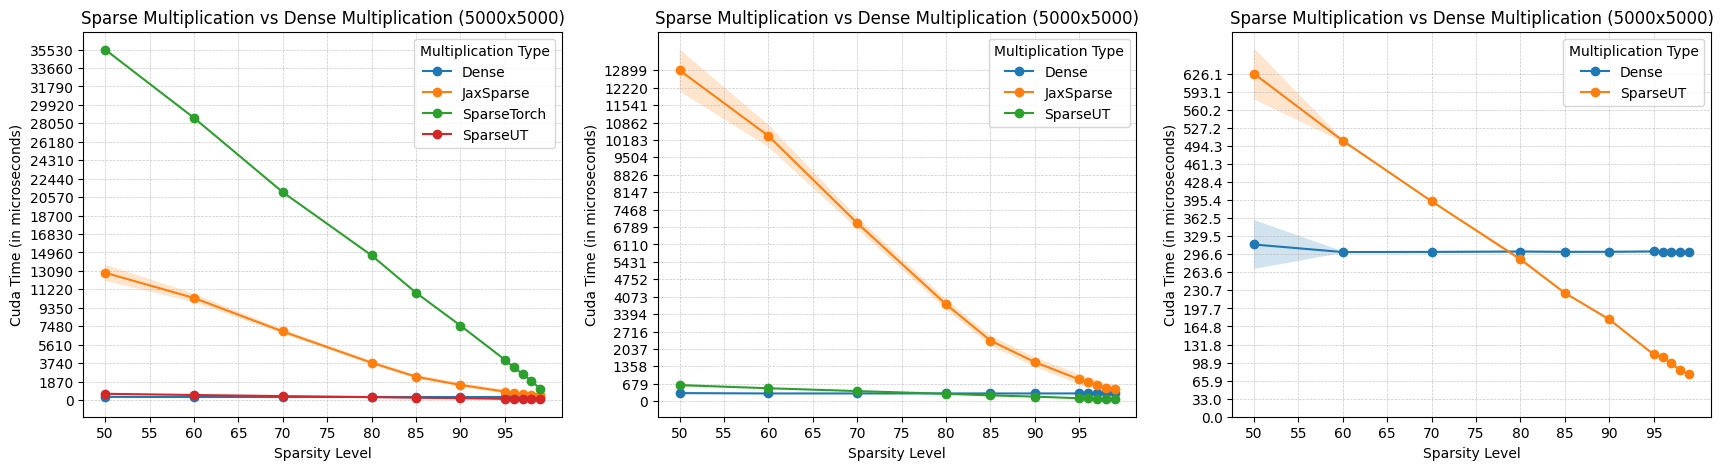

In [3]:

fig, ax = plt.subplots(1,3,figsize=(21, 5));
bz = 1
df_dlvl = df[(df.dense_level == dense_level) & (df.batch_size == bz)]
print(df_dlvl.shape)
plt.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)

def plt_them(df_dlvl, ax=None):

    
    max_min_avg_s = 0
    
        
    for category, group in df_dlvl.groupby('isSparse'):
        avg_per_sparsity = group.groupby('sparsity_level')['cuda_elapsed_time'].mean() * 10
        std_per_sparsity = group.groupby('sparsity_level')['cuda_elapsed_time'].std() * 10
        sparsity_level = group.groupby('sparsity_level')['sparsity_level'].first()
        max_min_avg_s = max(max_min_avg_s, avg_per_sparsity.max())
        
        ax.plot(sparsity_level, avg_per_sparsity, marker='o', linestyle='-', label=category)
        ax.fill_between(sparsity_level, avg_per_sparsity - std_per_sparsity, avg_per_sparsity + std_per_sparsity, alpha=0.2)

    ax.set_xticks(list(range(int(df_dlvl.sparsity_level.min()), 100, 5)))
    ax.set_yticks(np.linspace(0, max_min_avg_s, 20))
    
    ax.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)
    
    ax.set_title(f'Sparse Multiplication vs Dense Multiplication ({dense_level})')
    ax.set_xlabel('Sparsity Level')
    ax.set_ylabel('Cuda Time (in microseconds)')
    
    ax.legend(title='Multiplication Type')

    
    #return fig, ax  # Return figure and axis
plt_them(df_dlvl, ax=ax[0])

df_dlvl = df_dlvl[df_dlvl.dense_level == dense_level] 

plt.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)

# Group by the 'category' column and plot each group
df_dlvl=df_dlvl[df_dlvl.isSparse != 'SparseTorch']
plt_them(df_dlvl, ax=ax[1])



plt.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)

# Group by the 'category' column and plot each group
df_dlvl=df_dlvl[~df_dlvl.isSparse.isin(['SparseTorch', 'JaxSparse'])]
plt_them(df_dlvl, ax[2])
display(df_dlvl)

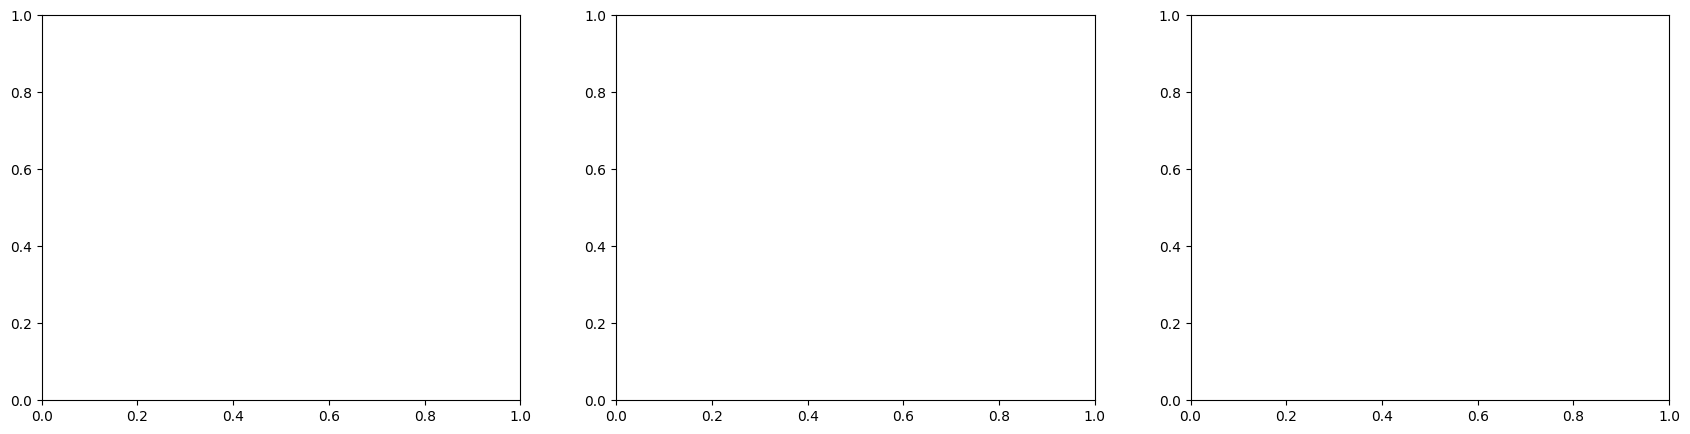

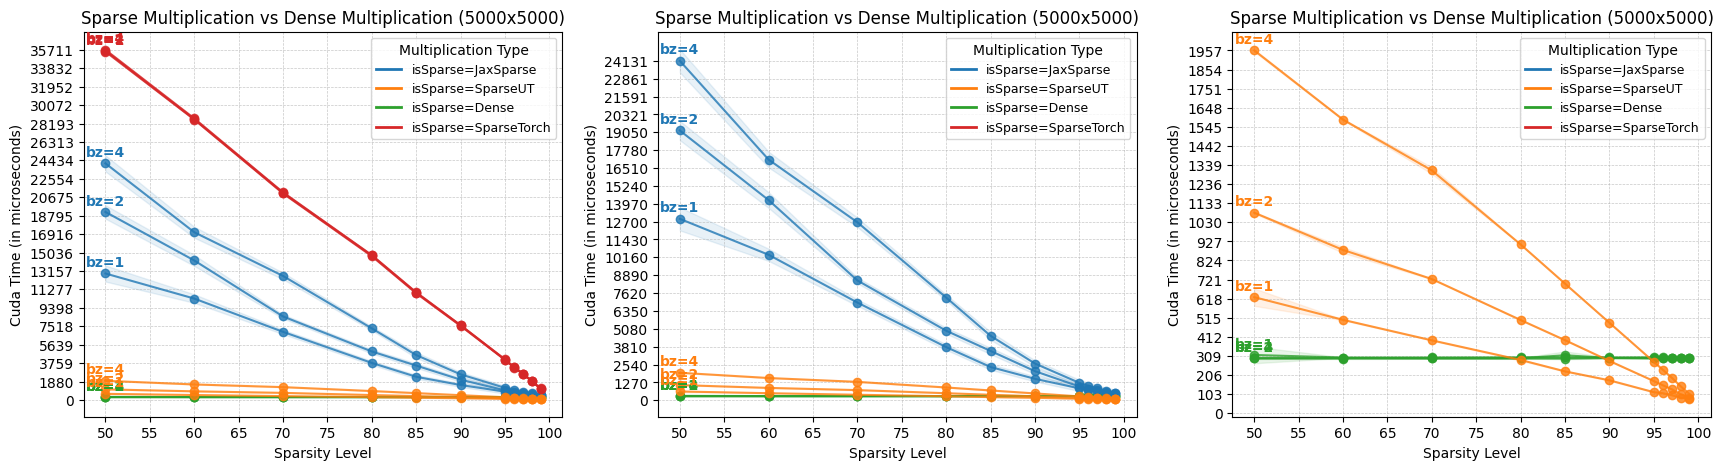

In [11]:
import seaborn as sns
fig, ax = plt.subplots(1,3,figsize=(21, 5));
def plt_them(df_dlvl, ax=None, tot=4):
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 6))

    max_min_avg_s = 0
    colors = plt.cm.tab10.colors  # Assign colors per isSparse
    color_map = {category: colors[i] for i, category in enumerate(df['isSparse'].unique())}

    for is_sparse, group_sparse in df_dlvl.groupby('isSparse'):
        for batch_size, group_batch in group_sparse.groupby('batch_size'):
            avg_per_sparsity = group_batch.groupby('sparsity_level')['cuda_elapsed_time'].mean() * 10
            std_per_sparsity = group_batch.groupby('sparsity_level')['cuda_elapsed_time'].std() * 10
            sparsity_level = group_batch.groupby('sparsity_level')['sparsity_level'].first()
            max_min_avg_s = max(max_min_avg_s, avg_per_sparsity.max())

            ax.plot(sparsity_level, avg_per_sparsity, linestyle='-', marker='o', 
                    color=color_map[is_sparse], alpha=0.8)
            ax.fill_between(sparsity_level, avg_per_sparsity - std_per_sparsity, 
                            avg_per_sparsity + std_per_sparsity, alpha=0.1, color=color_map[is_sparse])

            # Annotate batch size on the middle of the line
            mid_idx = len(sparsity_level) // 2
            ax.annotate(f'bz={batch_size}', 
                        (sparsity_level.iloc[0], avg_per_sparsity.iloc[0]), 
                        textcoords="offset points", xytext=(0,5), ha='center', fontsize=10, 
                        color=color_map[is_sparse], fontweight='bold')

    ax.set_xticks(list(range(df_dlvl.sparsity_level.min(), 101, 5)))
    ax.set_yticks(np.linspace(0, max_min_avg_s, 20))
    
    ax.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)
    
    ax.set_title(f'Sparse Multiplication vs Dense Multiplication ({dense_level})')
    ax.set_xlabel('Sparsity Level')
    ax.set_ylabel('Cuda Time (in microseconds)')
    
    # Custom legend for isSparse categories
    handles = [plt.Line2D([0], [0], color=color_map[cat], lw=2, label=f'isSparse={cat}') 
               for cat in color_map.keys()]
    ax.legend(handles=handles, title='Multiplication Type', loc='upper right', fontsize=9)

    return ax
def create_multi_plot_for_batches(BATCHES):
    fig, ax = plt.subplots(1,3,figsize=(21, 5));

    df_dlvl = df[(df.dense_level == dense_level) & (df.batch_size.isin(BATCHES))]
    plt_them(df_dlvl, ax=ax[0])
    
    
    plt.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)
    
    # Group by the 'category' column and plot each group
    df_dlvl=df_dlvl[df_dlvl.isSparse != 'SparseTorch']
    plt_them(df_dlvl, ax=ax[1])
    
    
    
    plt.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)
    
    # Group by the 'category' column and plot each group
    df_dlvl=df_dlvl[~df_dlvl.isSparse.isin(['SparseTorch', 'JaxSparse'])]
    plt_them(df_dlvl, ax[2])
    plt.show()

create_multi_plot_for_batches([1,2, 4])
#create_multi_plot_for_batches([4, 8, 15, 32])




